In [3]:
"""
Model Reproduction Script
- Load saved train / test data directly
- Reconstruct the GNN + Transformer + Condition Concatenation model
- Load best_model.pt
- Calculate and print MAE / RMSE / MSE / R2
"""

import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from rdkit import Chem
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# In newer versions of torch_geometric, 'Dataset' is typically imported from torch_geometric.data
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# Set random seed (consistent with training)
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# Atom / Bond features (completely consistent with training)
# =========================================================
MAX_ATOMIC_NUM = 100
_hybridization_list = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]

def atom_features(atom):
    at_num = min(max(atom.GetAtomicNum(), 1), MAX_ATOMIC_NUM)
    at_onehot = np.zeros(MAX_ATOMIC_NUM, dtype=np.float32)
    at_onehot[at_num - 1] = 1.0
    degree = atom.GetDegree()
    charge = atom.GetFormalCharge()
    aromatic = float(atom.GetIsAromatic())
    num_h = atom.GetTotalNumHs()
    try:
        hyb = _hybridization_list.index(atom.GetHybridization())
        hyb_onehot = np.zeros(len(_hybridization_list), dtype=np.float32)
        hyb_onehot[hyb] = 1.0
    except ValueError:
        hyb_onehot = np.zeros(len(_hybridization_list), dtype=np.float32)
    return np.concatenate([at_onehot, [degree, charge, aromatic, num_h], hyb_onehot])

def bond_features(bond):
    bt_onehot = np.zeros(4, dtype=np.float32)
    bt = bond.GetBondType()
    if bt == Chem.rdchem.BondType.SINGLE: bt_onehot[0] = 1
    elif bt == Chem.rdchem.BondType.DOUBLE: bt_onehot[1] = 1
    elif bt == Chem.rdchem.BondType.TRIPLE: bt_onehot[2] = 1
    elif bt == Chem.rdchem.BondType.AROMATIC: bt_onehot[3] = 1
    return np.concatenate([bt_onehot, [float(bond.GetIsConjugated()), float(bond.IsInRing())]])

# =========================================================
# Dataset (completely consistent with training)
# =========================================================
class ReactionDataset(Dataset):
    def __init__(self, dataframe, scaler):
        super().__init__()
        self.df = dataframe.reset_index(drop=True)
        self.scaler = scaler

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mol = Chem.MolFromSmiles(row['structure'])
        x = torch.tensor(np.vstack([atom_features(a) for a in mol.GetAtoms()]), dtype=torch.float)

        edge_index, edge_attr = [], []
        for bond in mol.GetBonds():
            i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            bf = bond_features(bond)
            edge_index += [[i, j], [j, i]]
            edge_attr += [bf, bf]

        if edge_index:
            edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
            edge_attr = torch.tensor(np.vstack(edge_attr), dtype=torch.float)
        else:
            edge_index = torch.zeros((2, 0), dtype=torch.long)
            edge_attr = torch.zeros((0, 6), dtype=torch.float)

        cond = self.scaler.transform(
            np.array([[row['Al/M'], row['T'], row['P'], row['t']]], dtype=np.float32)
        ).reshape(-1)

        y = torch.tensor([row['Act']], dtype=torch.float)

        return Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=y,
            cond=torch.tensor(cond, dtype=torch.float)
        )

# =========================================================
# Model Definition 
# =========================================================
class GNNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=256, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for i in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(in_dim if i == 0 else hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.convs.append(GINConv(mlp))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

    def forward(self, x, edge_index):
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, edge_index)))
        return x

class TransformerNodeEnhancer(nn.Module):
    def __init__(self, dim=256, layers=4, heads=8):
        super().__init__()
        enc_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=heads,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=layers)

    def forward(self, x, mask):
        return self.encoder(x, src_key_padding_mask=mask)

class ReactionModel(nn.Module):
    def __init__(self,
                 node_in_dim,
                 gnn_hidden=256,
                 gnn_layers=3,
                 trans_layers=4,
                 trans_heads=8,
                 cond_dim=64,
                 fusion_hidden=128):
        super().__init__()

        self.gnn = GNNEncoder(node_in_dim, gnn_hidden, gnn_layers)
        self.node_proj = nn.Linear(gnn_hidden, gnn_hidden)
        self.trans = TransformerNodeEnhancer(gnn_hidden, trans_layers, trans_heads)

        self.cond_enc = nn.Sequential(
            nn.Linear(4, cond_dim),
            nn.ReLU(),
            nn.Linear(cond_dim, cond_dim)
        )

        self.mlp = nn.Sequential(
            nn.Linear(gnn_hidden + cond_dim, fusion_hidden),   # 0
            nn.ReLU(),                                         # 1
            nn.Dropout(0.2),                                   # 2
            nn.Linear(fusion_hidden, fusion_hidden // 2),      # 3
            nn.ReLU(),                                         # 4
            nn.Linear(fusion_hidden // 2, 1)                   # 5
        )

    def forward(self, batch):
        h = self.gnn(batch.x, batch.edge_index)
        h = self.node_proj(h)

        counts = torch.bincount(batch.batch)
        max_n = counts.max().item()
        B = batch.num_graphs
        device = h.device

        node_tensor = torch.zeros((B, max_n, h.size(1)), device=device)
        mask = torch.ones((B, max_n), dtype=torch.bool, device=device)

        ptr = 0
        for i, n in enumerate(counts):
            node_tensor[i, :n] = h[ptr:ptr+n]
            mask[i, :n] = False
            ptr += n

        h = self.trans(node_tensor, mask)
        pooled = (h * (~mask).unsqueeze(-1)).sum(1) / (~mask).sum(1, keepdim=True)

        cond = batch.cond.view(-1, 4)
        cond_emb = self.cond_enc(cond)

        return self.mlp(torch.cat([pooled, cond_emb], 1)).squeeze(-1)

# =========================================================
# Evaluation Function
# =========================================================
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for batch in loader:
        batch = batch.to(device)
        y_pred.append(model(batch).cpu().numpy())
        y_true.append(batch.y.view(-1).cpu().numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# =========================================================
# Main Reproduction Workflow
# =========================================================
train_df = pd.read_csv(r"D:\works\PE\code\GNN模型\train_dataset.csv")
test_df  = pd.read_csv(r"D:\works\PE\code\GNN模型\test_dataset.csv")

scaler = StandardScaler().fit(train_df[['Al/M', 'T', 'P', 't']])

train_ds = ReactionDataset(train_df, scaler)
test_ds  = ReactionDataset(test_df, scaler)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

node_dim = train_ds[0].x.size(1)
model = ReactionModel(node_dim).to(device)

model.load_state_dict(torch.load("best_model.pt", map_location=device))

train_metrics = evaluate(model, train_loader)
test_metrics  = evaluate(model, test_loader)

print("\n===== Train Metrics =====")
for k, v in train_metrics.items():
    print(f"{k}: {v:.6f}")

print("\n===== Test Metrics =====")
for k, v in test_metrics.items():
    print(f"{k}: {v:.6f}")


===== Train Metrics =====
MAE: 0.053478
RMSE: 0.066338
MSE: 0.004401
R2: 0.803391

===== Test Metrics =====
MAE: 0.064266
RMSE: 0.092437
MSE: 0.008545
R2: 0.774779


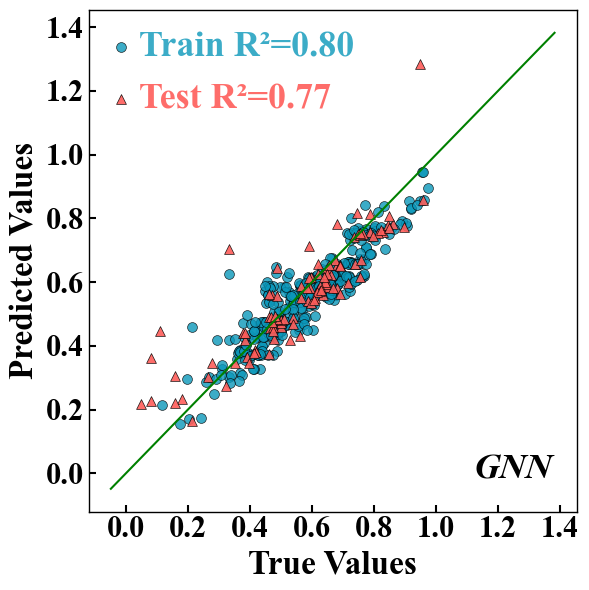

In [9]:
# =========================================================
# 1. 提取绘图所需数据 (在 evaluate 之后添加)
# =========================================================
# 定义一个简单的获取原始值的函数
def get_raw_values(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            y_pred.append(model(batch).cpu().numpy())
            y_true.append(batch.y.view(-1).cpu().numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)

# 获取训练集和测试集的坐标点
train_y_true, train_y_pred = get_raw_values(model, train_loader)
test_y_true, test_y_pred = get_raw_values(model, test_loader)

# =========================================================
# 2. 绘制散点图 (修改后的绘图代码)
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.ticker as ticker
import matplotlib.ticker as mtick

plt.figure(figsize=(6, 6))

# 修改点：使用提取出的 train_y_true 和 train_y_pred
# 动态填入 metrics 结果 (可选，若不改动内容则保持原样字符串)
plt.scatter(train_y_true, train_y_pred, alpha=0.8, color="#0b97ba", edgecolors="black", 
            linewidths=0.5,label='Train R²=0.80', s=50)

# 修改点：使用提取出的 test_y_true 和 test_y_pred
plt.scatter(test_y_true, test_y_pred, alpha=0.9, color="#fe5d5a", edgecolors="black", 
            linewidths=0.5, label=f'Test R²={test_metrics["R2"]:.2f}', s=50, marker='^')

# 添加理想预测线（y=x）
# 修改点：min/max 的变量名同步修改
min_val = min(min(test_y_true), min(test_y_pred), min(train_y_true), min(train_y_pred))
max_val = max(max(test_y_true), max(test_y_pred), max(train_y_true), max(train_y_pred))
padding = (max_val - min_val) * 0.08  # 线段延长

plt.plot(
    [min_val - padding, max_val + padding],
    [min_val - padding, max_val + padding],
    color='green'
)

# 调整图例（legend）
# ================================
leg = plt.legend(
    loc='upper left',
    prop={'family': 'Times New Roman', 'weight': 'bold', 'size': 26},
     frameon=False,   # ✅ 关闭图例边框
     bbox_to_anchor=(0, 0.95),
     handletextpad=-0.5 ,
     borderaxespad=-0.5   
)
handles = leg.legend_handles
texts = leg.get_texts()

for handle, text in zip(handles, texts):
    try:
        text.set_color(handle.get_facecolor()[0])  
    except:
        text.set_color(handle.get_color())          

# ============================
# 坐标轴标题设置
# ============================
plt.xlabel('True Values', fontsize=24, fontweight='bold', fontfamily='Times New Roman')
plt.ylabel('Predicted Values', fontsize=24, fontweight='bold', fontfamily='Times New Roman')

ax = plt.gca()

# 添加文字标记
ax.text(
    0.95, 0.05,          # 坐标位置：x=0.95 (接近右边缘), y=0.05 (接近底部)
    'GNN',               # 内容
    transform=ax.transAxes,  # 关键：使用轴坐标系 (0到1)
    fontsize=26,         # 字体大小
    fontweight='bold',   # 加粗
    fontfamily='Times New Roman',
    fontstyle='italic',  # ✅ 设置为斜体
    ha='right',          # 水平对齐：右对齐
    va='bottom',         # 垂直对齐：底部对齐
    # bbox=dict(facecolor='white', alpha=0.5, edgecolor='none') # 可选：如果背景太花可以加个半透明底色
)
# ==
ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=5,
    width=1.5
)

plt.xticks(fontsize=22, fontweight='bold', fontfamily='Times New Roman')
plt.yticks(fontsize=22, fontweight='bold', fontfamily='Times New Roman')

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.tight_layout()
# 路径修改为原始字符串防止转义
plt.savefig(r"D:\works\PE\稿件\Figure\All_models_metal\GNN.png", dpi=300, bbox_inches='tight')
plt.show()